In [1]:
import os
import json
import matplotlib.pyplot as plt
from collections import defaultdict
import pandas as pd
import numpy as np


from sandbox.plt_dict import matplotlib_update
matplotlib_update()

def plot_model_results(folder_path, epsilons, d_train, kl_plot=True, acc_plot=True, acc_pm_plot=True, acc_within=2, plot_filename=""):
    """
    Parses result JSONs and plots KL-loss and Accuracy across dimensions d.
    """
    # Data structure: { epsilon: { d_value: {'kl': [], 'acc': []} } }
    data = defaultdict(lambda: defaultdict(lambda: {'kl': None, 'acc': None, 'acc_pm': None}))
    
    # 1. Data Extraction
    for filename in os.listdir(folder_path):
        if filename.startswith("results_") and filename.endswith(".json"):
            try:
                d = int(filename.split('_')[1].split('.')[0])
            except ValueError:
                continue
                
            file_path = os.path.join(folder_path, filename)
            with open(file_path, 'r') as f:
                results = json.load(f)
            
            for entry in results:
                curr_eps = entry.get("eps")
                if curr_eps in epsilons:
                    preds = entry.get("predicted_classes", [])
                    trues = entry.get("true_classes", [])

                    acc = sum(1 for p, t in zip(preds, trues) if p == t) / len(trues) if trues else 0
                    acc_pm = sum(1 for p, t in zip(preds, trues) if abs(p-t)<=acc_within) / len(trues) if trues else 0
                    
                    data[curr_eps][d]['kl'] = entry.get("kl_avg")
                    data[curr_eps][d]['acc'] = acc
                    data[curr_eps][d]['acc_pm'] = acc_pm

    # 2. Preparation for Plotting
    sorted_eps = sorted(epsilons, key=lambda x: (str(type(x)), x))
    
    # --- FIGURE 1: KL Loss ---
    if kl_plot:
        plt.figure()
        for eps in sorted_eps:
            sorted_ds = sorted(data[eps].keys())
            kl_vals = [data[eps][d]['kl'] for d in sorted_ds]
            label = f"$\epsilon$ = {eps}" if eps != 'ortho' else "Ortho"
            plt.plot(sorted_ds, kl_vals, marker='o', label=label)

        for d_val in d_train:
            plt.axvline(x=d_val, color='gray', linestyle='--', alpha=0.5)
            plt.text(d_val, plt.gca().get_ylim()[0], f' $d={d_val}$', 
                    rotation=90, verticalalignment='bottom', fontsize=8, color='gray')

        plt.xlabel("Dimension ($d$)")
        plt.ylabel("Loss")
        plt.legend()
        plt.grid(True, which='both', linestyle=':', alpha=0.5)
        plt.tight_layout()

        if plot_filename:
            plt.savefig(plot_filename + "_loss.pdf")

    # --- FIGURE 2: Accuracy ---
    if acc_plot:
        plt.figure()
        sorted_ds = sorted(data[sorted_eps[0]].keys())
        d_min = sorted_ds[0]
        d_max = sorted_ds[-1]
        for eps in sorted_eps:
            sorted_ds = sorted(data[eps].keys())
            acc_vals = [data[eps][d]['acc'] for d in sorted_ds]
            label = f"$\epsilon$ = {eps}" if eps != 'ortho' else "Ortho"
            plt.plot(sorted_ds, acc_vals, marker='s', label=label)

        # plt.plot(d_grid := range(d_min, d_max+1), [1/d for d in d_grid], ':', color='black', alpha=0.6)

        for d_val in d_train:
            plt.axvline(x=d_val, color='gray', linestyle='--', alpha=0.5)
            plt.text(d_val, plt.gca().get_ylim()[0], f' $d={d_val}$', 
                    rotation=90, verticalalignment='bottom', fontsize=8, color='gray')

        plt.xlabel("Dimension ($d$)")
        plt.ylabel("Accuracy")
        plt.legend()
        plt.grid(True, linestyle=':', alpha=0.6)
        plt.tight_layout()
        
        if plot_filename:
            plt.savefig(plot_filename + "_accuracy.pdf")

        plt.show()

    # --- FIGURE 3: Accuracy within ---
    if acc_pm_plot:
        plt.figure()
        for eps in sorted_eps:
            sorted_ds = sorted(data[eps].keys())
            acc_vals = [data[eps][d]['acc_pm'] for d in sorted_ds]
            label = f"$\epsilon$ = {eps}" if eps != 'ortho' else "Ortho"
            plt.plot(sorted_ds, acc_vals, marker='s', label=label)

        for d_val in d_train:
            plt.axvline(x=d_val, color='gray', linestyle='--', alpha=0.5)
            plt.text(d_val, plt.gca().get_ylim()[0], f' $d={d_val}$', 
                    rotation=90, verticalalignment='bottom', fontsize=8, color='gray')

        plt.xlabel("Dimension ($d$)")
        plt.ylabel(f"Accuracy@$\\pm${acc_within}")
        plt.legend()
        plt.grid(True, linestyle=':', alpha=0.6)
        plt.tight_layout()
        
        if plot_filename:
            plt.savefig(plot_filename + f"_accuracy_at_{acc_within}.pdf")

        plt.show()

In [2]:
def model_results_to_pandas(folder_path, epsilons, d_train, acc_within=2):
    """
    Parses result JSONs and plots KL-loss and Accuracy across dimensions d.
    """
    # Data structure: { epsilon: { d_value: {'kl': [], 'acc': []} } }
    data = defaultdict(lambda: defaultdict(lambda: {'kl': None, 'acc': None, 'acc_pm': None}))
    
    # 1. Data Extraction
    for filename in os.listdir(folder_path):
        if filename.startswith("results_") and filename.endswith(".json"):
            try:
                d = int(filename.split('_')[1].split('.')[0])
            except ValueError:
                continue
                
            file_path = os.path.join(folder_path, filename)
            with open(file_path, 'r') as f:
                results = json.load(f)
            
            for entry in results:
                curr_eps = entry.get("eps")
                if curr_eps in epsilons:
                    preds = entry.get("predicted_classes", [])
                    trues = entry.get("true_classes", [])

                    acc = sum(1 for p, t in zip(preds, trues) if p == t) / len(trues) if trues else 0
                    acc_pm = sum(1 for p, t in zip(preds, trues) if abs(p-t)<=acc_within) / len(trues) if trues else 0
                    
                    data[curr_eps][d]['kl'] = entry.get("kl_avg")
                    data[curr_eps][d]['acc'] = acc
                    data[curr_eps][d]['acc_pm'] = acc_pm

    df = pd.DataFrame.from_dict({(i, j): data[i][j] 
                        for i in data.keys() 
                        for j in data[i].keys()},
                    orient='index')

    # 2. Extract your three DataFrames
    # We unstack 'level 0' (which is 'eps') to move it to the columns
    df_kl = df['kl'].unstack(level=0)
    df_acc = df['acc'].unstack(level=0)
    df_acc_pm = df['acc_pm'].unstack(level=0)
    return df_kl, df_acc, df_acc_pm

In [3]:
pretrained_dimensions = [4, 6, 9, 12, 15, 28]

In [15]:
df_kl, df_acc, df_acc_pm = model_results_to_pandas('./sandbox/jordan8_results', [0.0, 1e-6, 1e-4, 1e-2], pretrained_dimensions, acc_within=1)

In [16]:
df_kl.round(decimals=2)

,0.000000,0.000001,0.000100,0.010000
4,0.10,0.02,0.46,0.65
6,0.08,0.04,0.65,0.47
7,0.10,0.03,0.58,1.09
9,0.03,0.23,1.50,0.58
12,0.03,0.29,1.85,1.81
13,0.08,0.09,0.81,0.79
15,0.06,0.34,1.20,0.46
19,0.09,0.06,0.78,0.76
23,0.11,0.11,0.69,1.05
25,0.07,0.08,0.74,1.39


In [17]:
df_kl_mod = df_kl.div(np.log(df_kl.index), axis=0)

In [18]:
df_kl_mod

,0.000000,0.000001,0.000100,0.010000
4,0.075707,0.015686,0.333413,0.468069
6,0.044994,0.022455,0.364021,0.265057
7,0.053905,0.015753,0.296899,0.561294
9,0.014240,0.103731,0.682007,0.263460
12,0.013183,0.117684,0.743002,0.727178
13,0.029561,0.035506,0.315408,0.309043
15,0.023894,0.123945,0.442241,0.169986
19,0.029037,0.020088,0.264602,0.258102
23,0.036092,0.036044,0.221214,0.333868
25,0.022694,0.023972,0.230826,0.433028


In [19]:
df_kl_mod = df_kl.div(df_kl.index, axis=0)

In [20]:
df_kl_mod

,0.000000,0.000001,0.000100,0.010000
4,0.026238,0.005436,0.115552,0.162220
6,0.013436,0.006706,0.108706,0.079153
7,0.014985,0.004379,0.082534,0.156033
9,0.003476,0.025324,0.166503,0.064320
12,0.002730,0.024369,0.153858,0.150581
13,0.005832,0.007005,0.062231,0.060975
15,0.004314,0.022377,0.079841,0.030689
19,0.004500,0.003113,0.041005,0.039998
23,0.004920,0.004914,0.030157,0.045515
25,0.002922,0.003086,0.029720,0.055755


In [21]:
df_acc.round(decimals=3)

,0.000000,0.000001,0.000100,0.010000
4,1.000,1.000,0.997,0.697
6,1.000,1.000,0.996,0.598
7,1.000,1.000,0.998,0.715
9,0.999,0.999,0.997,0.589
12,0.999,0.999,0.993,0.407
13,0.996,0.995,0.981,0.374
15,0.998,0.998,0.970,0.438
19,1.000,1.000,0.980,0.298
23,0.963,0.962,0.952,0.234
25,0.998,0.997,0.951,0.233


In [22]:
df_acc_pm.round(decimals=3)

,0.000000,0.000001,0.000100,0.010000
4,1.000,1.000,1.000,0.976
6,1.000,1.000,1.000,0.949
7,1.000,1.000,1.000,0.938
9,1.000,1.000,1.000,0.883
12,1.000,1.000,0.999,0.750
13,1.000,1.000,0.998,0.789
15,0.999,0.999,0.996,0.814
19,1.000,1.000,0.999,0.699
23,1.000,1.000,0.999,0.603
25,1.000,1.000,0.997,0.546


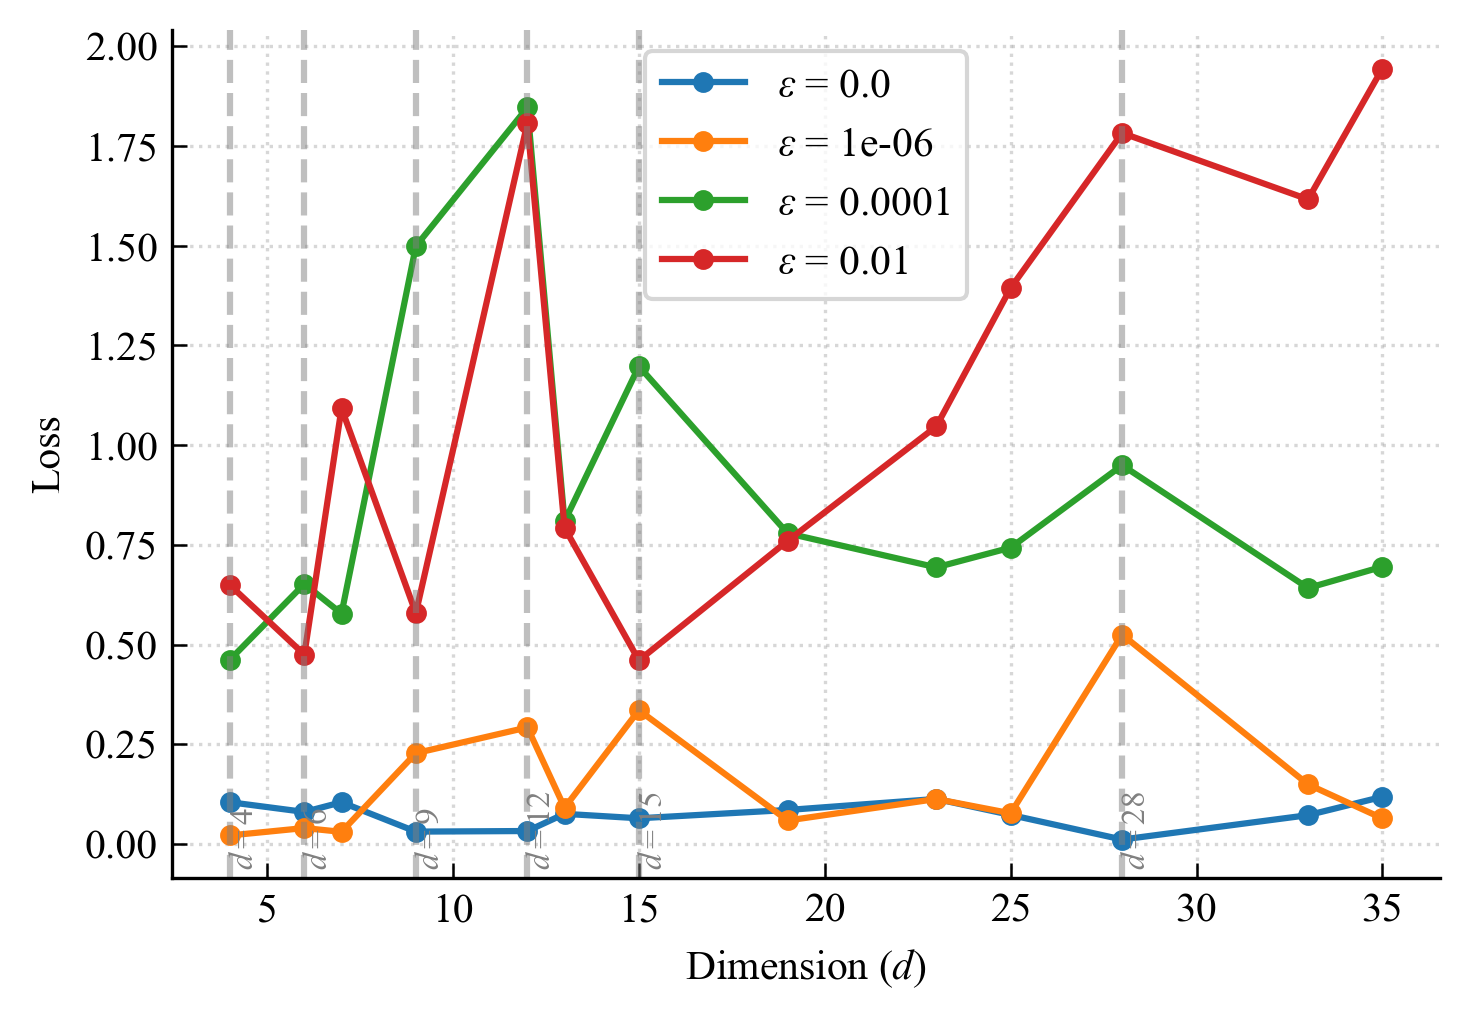

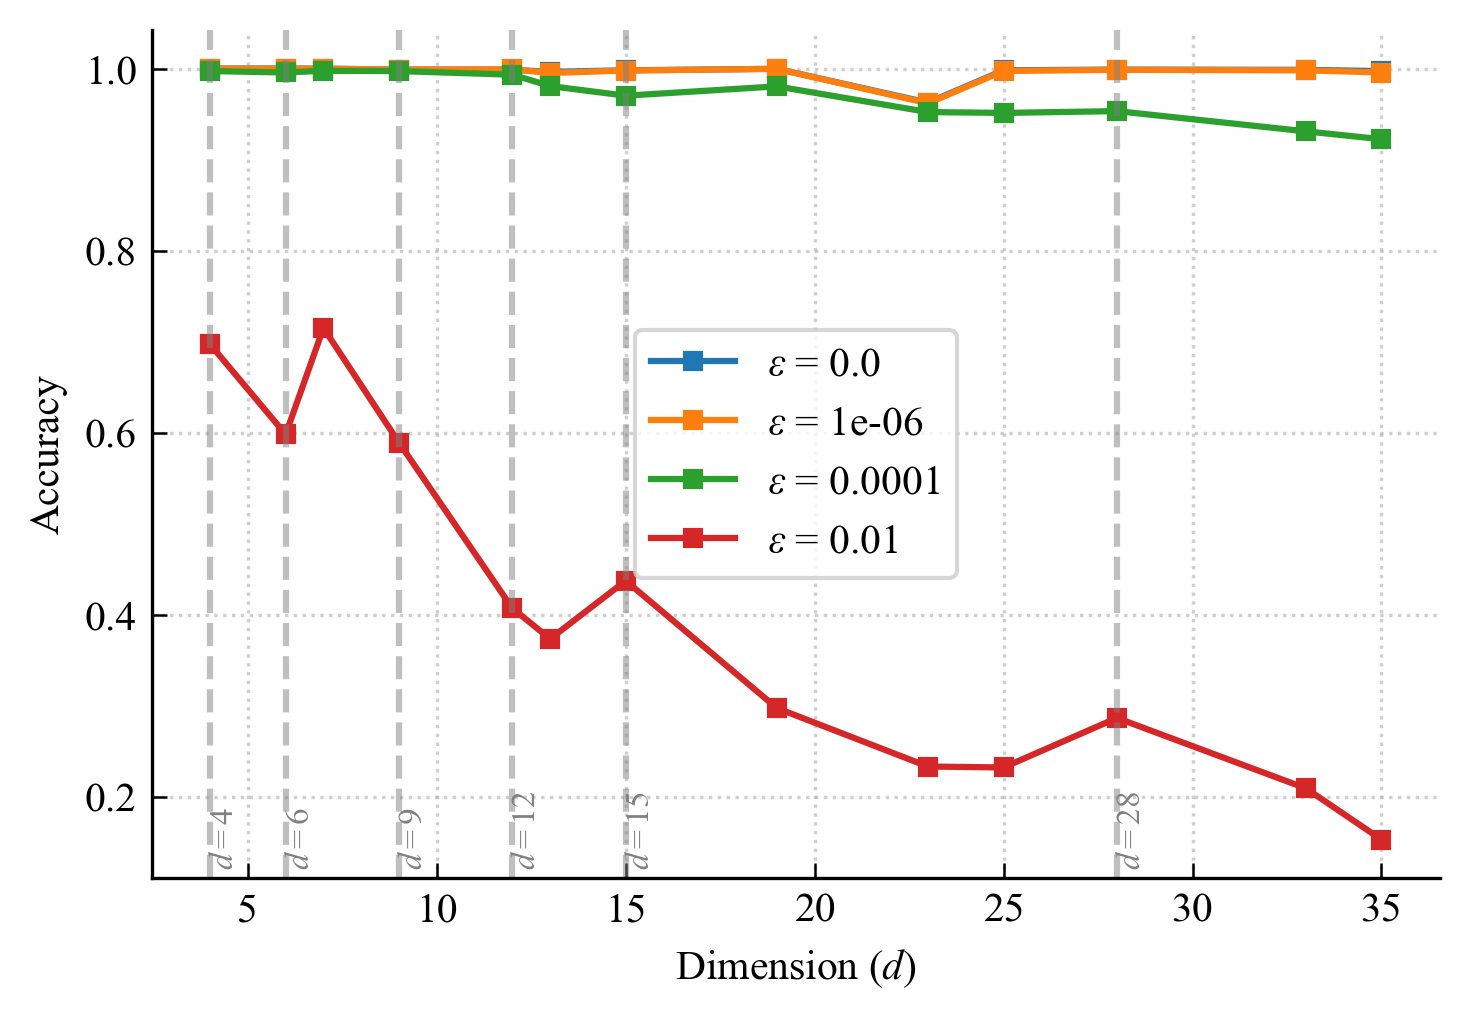

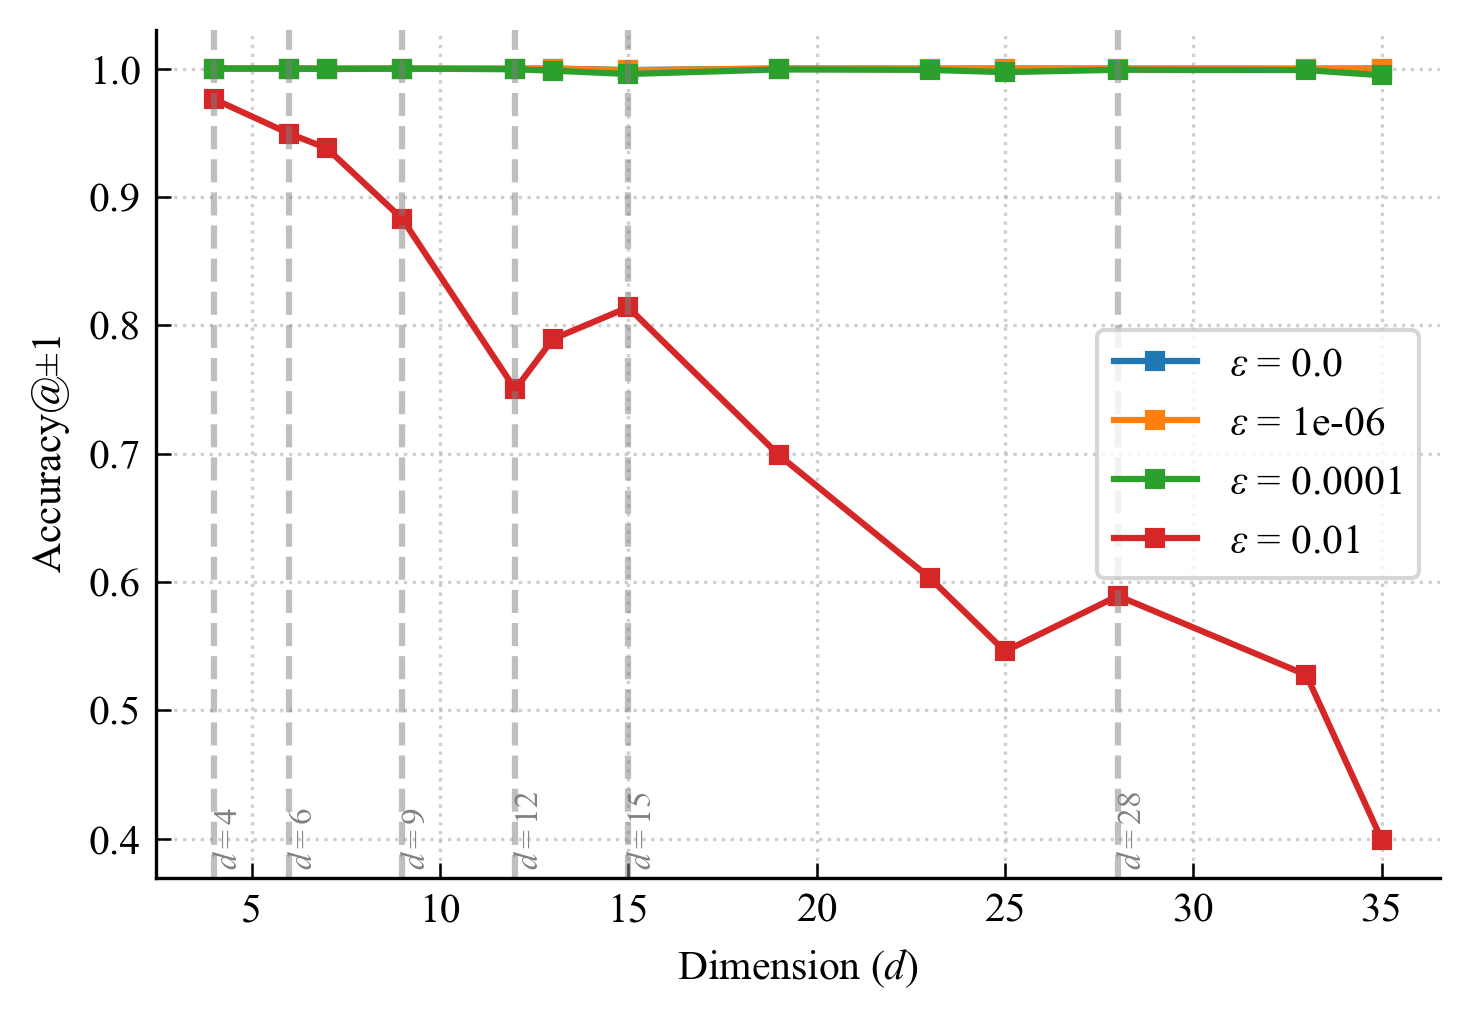

In [23]:
plot_model_results('./sandbox/jordan8_results', [0.0, 1e-6, 1e-4, 1e-2], pretrained_dimensions, plot_filename="latex/images/j8_a", kl_plot=True, acc_pm_plot=True, acc_within=1)

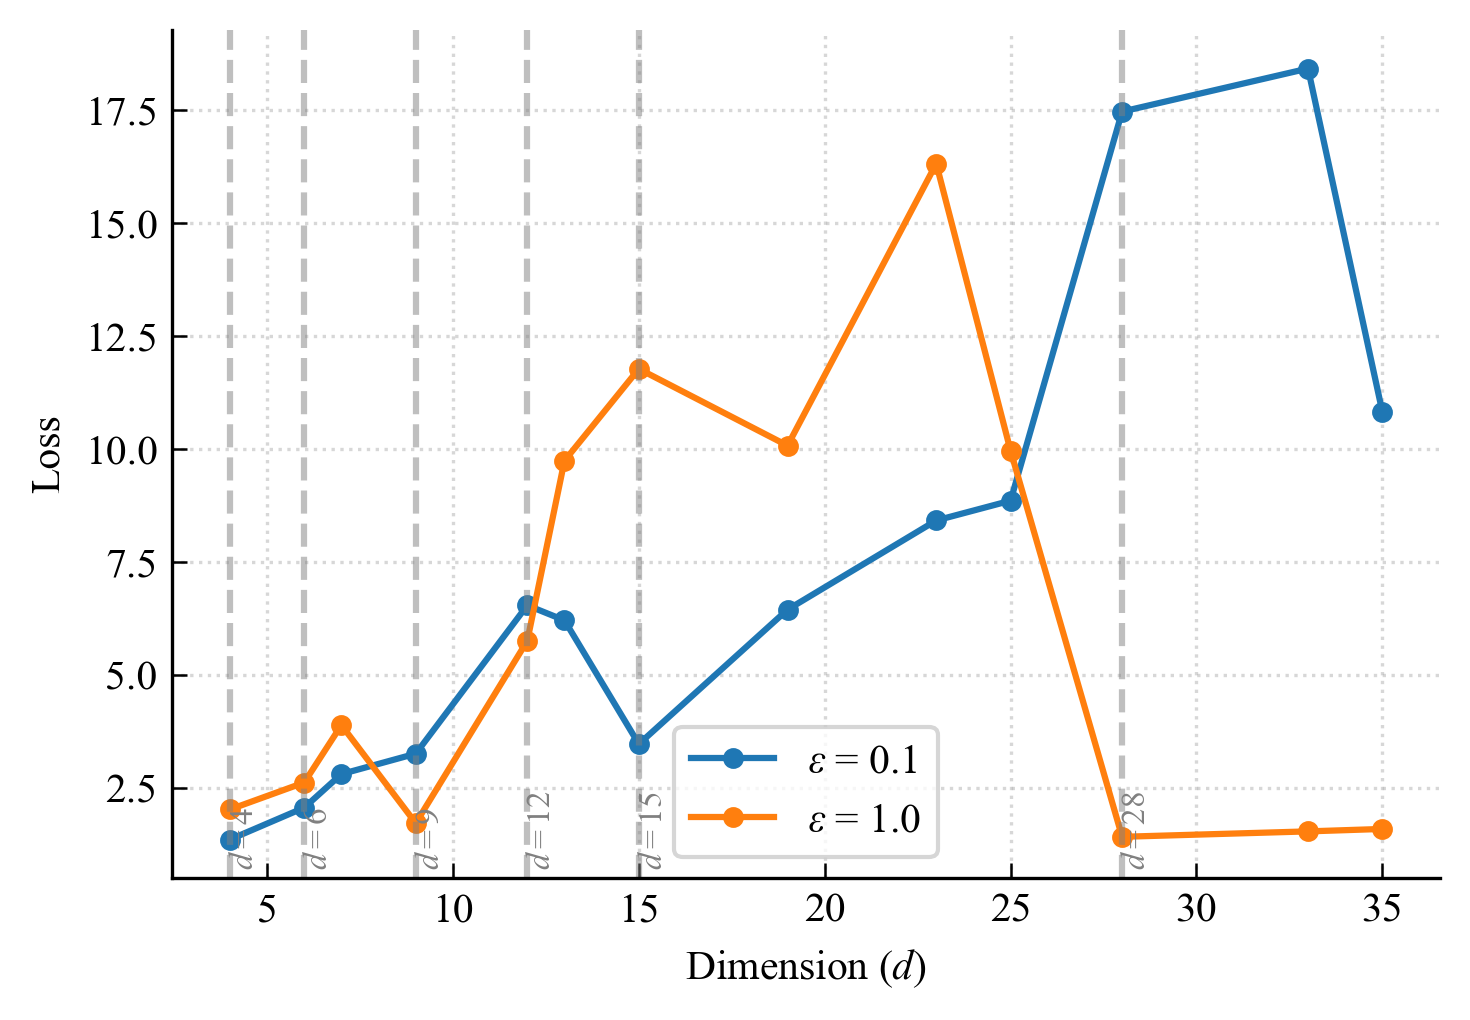

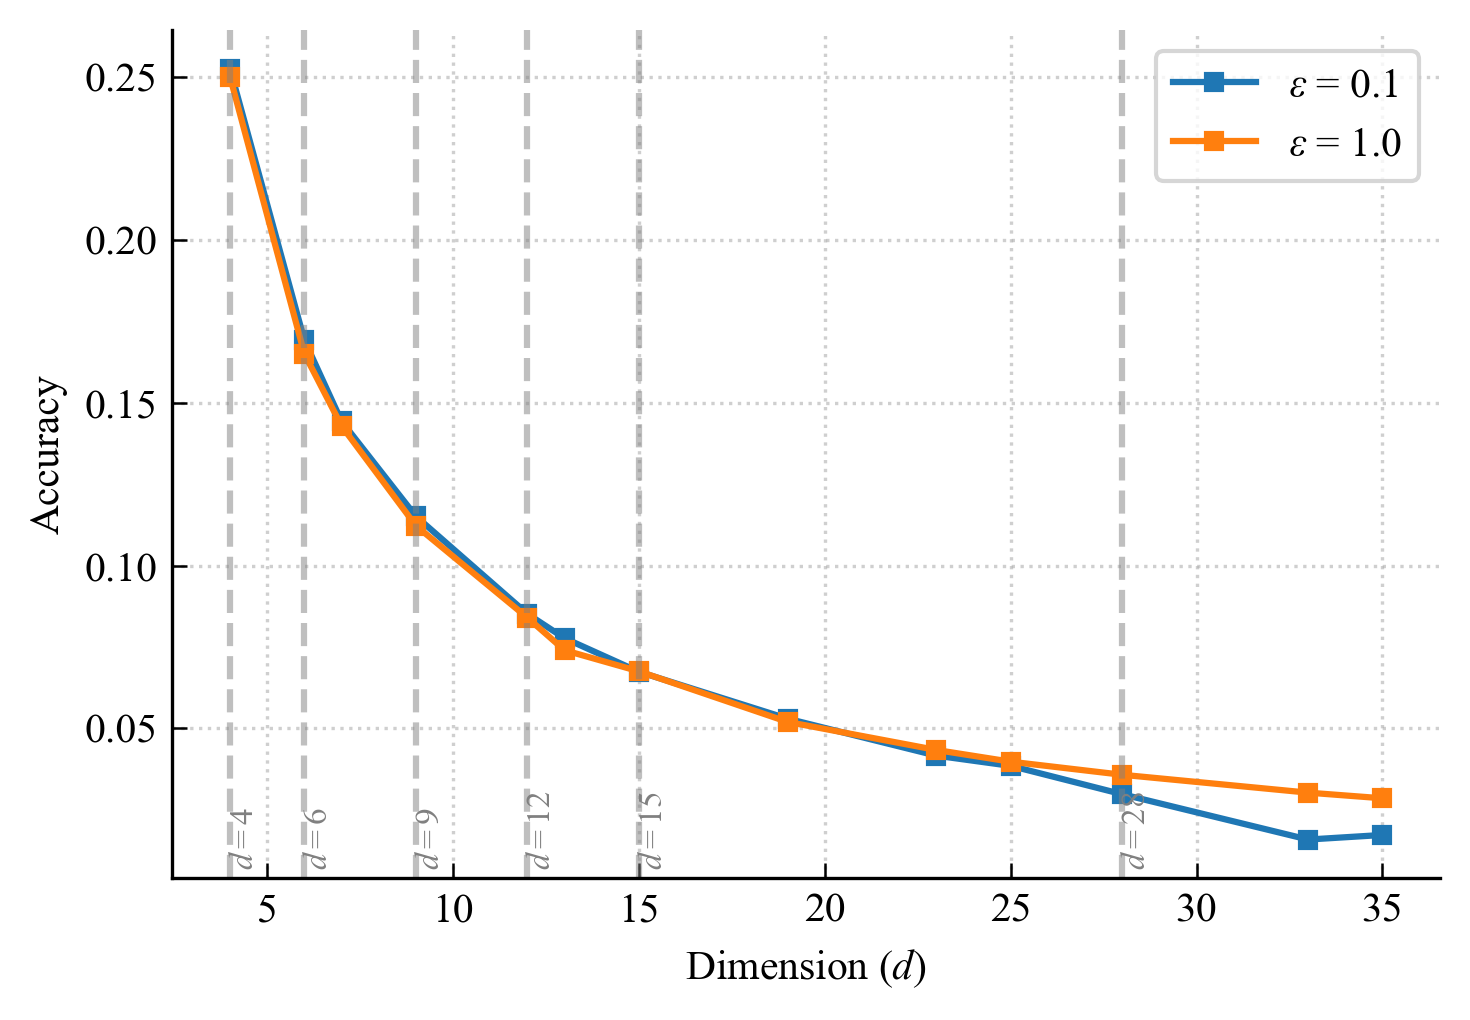

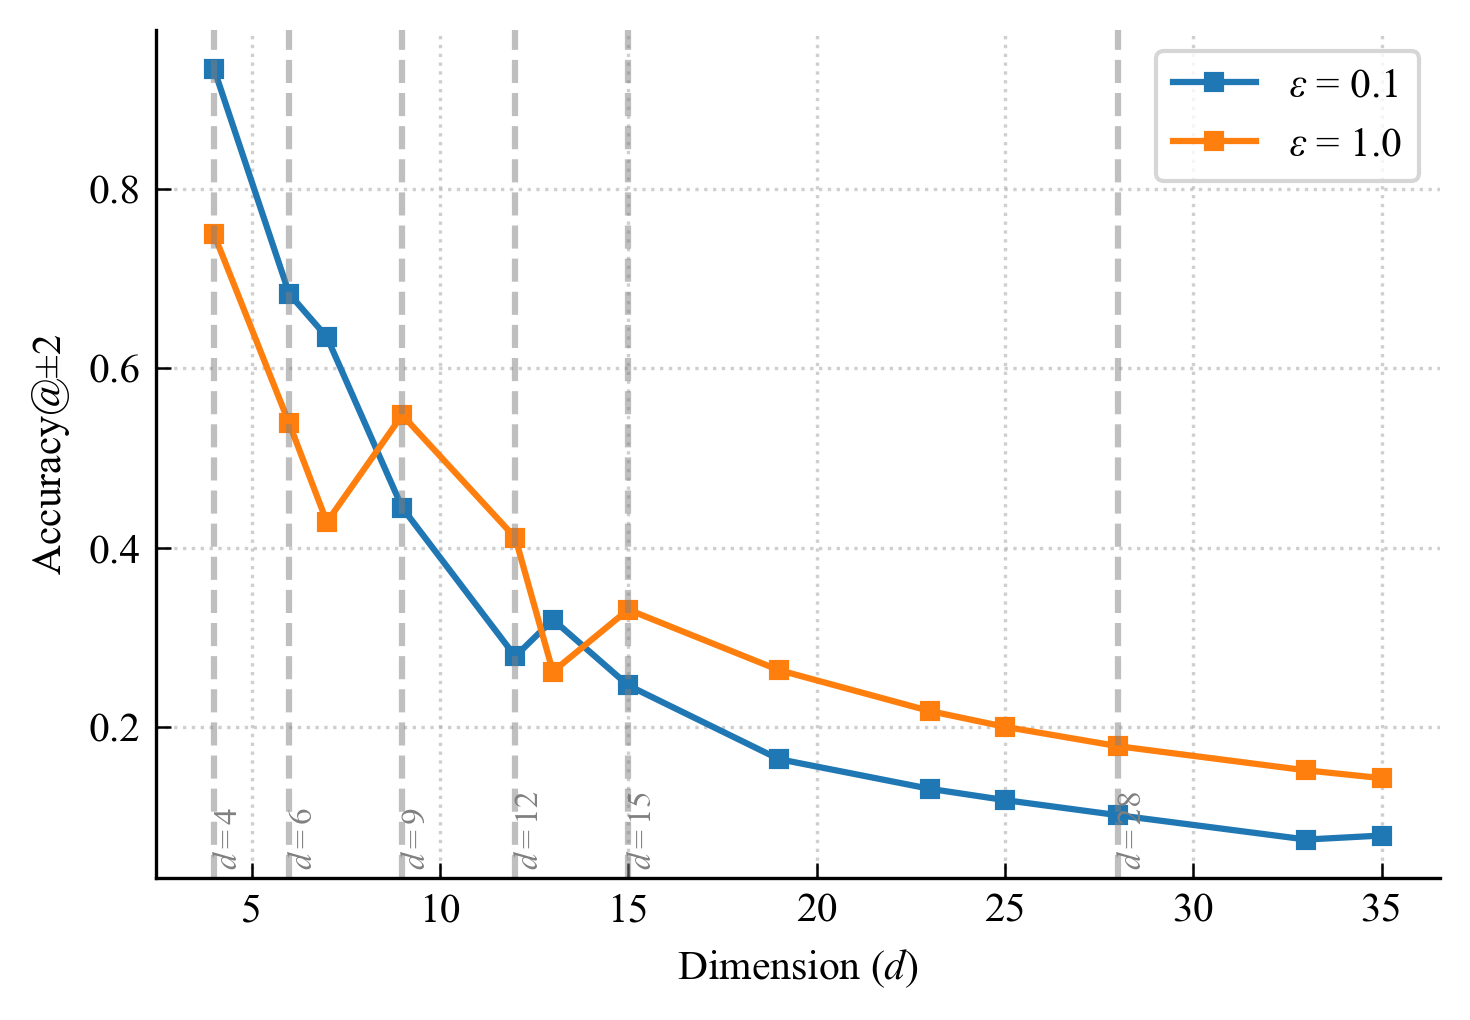

In [13]:
plot_model_results('./sandbox/jordan8_results', [0.1, 1.0], pretrained_dimensions, acc_within=2)

d = 12


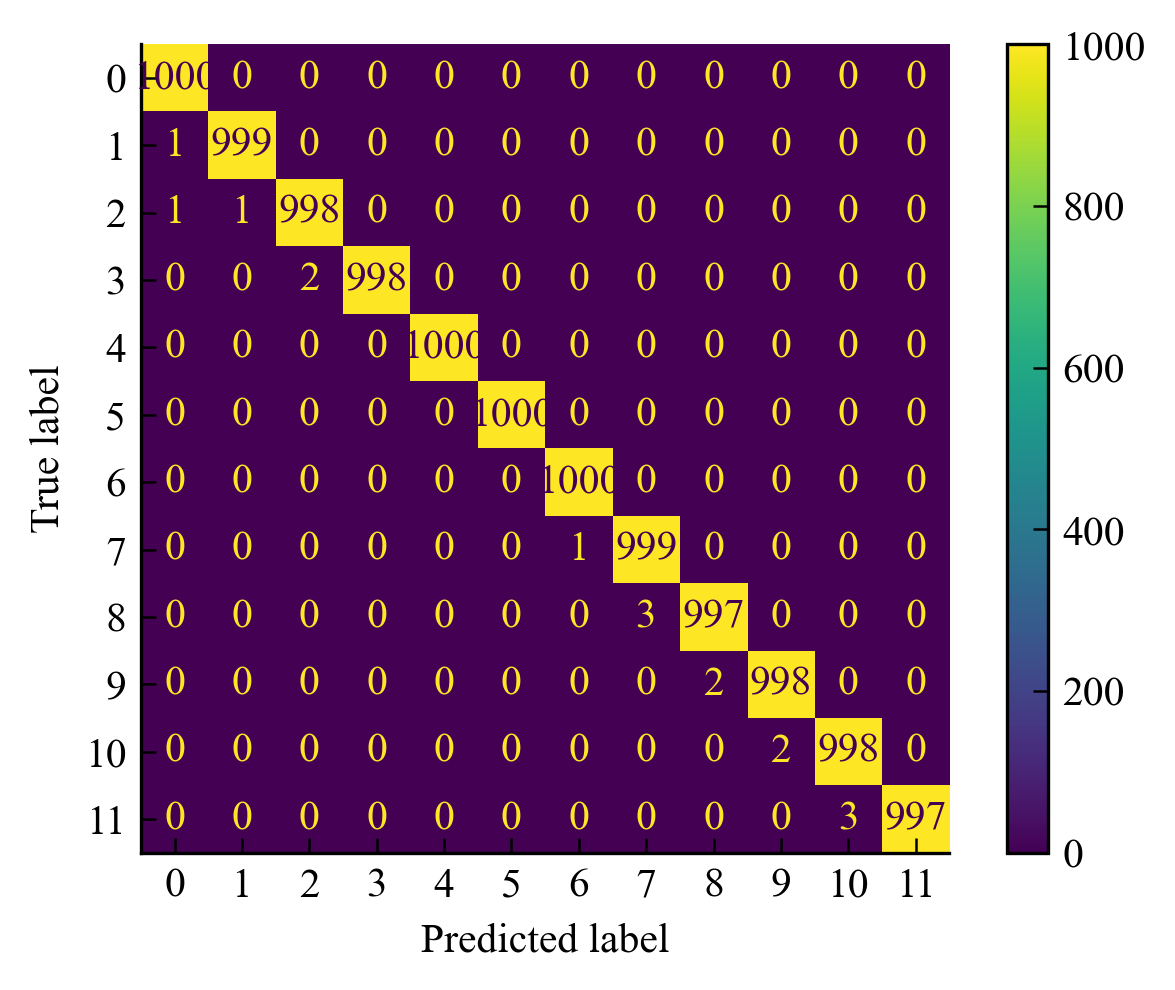

d = 13


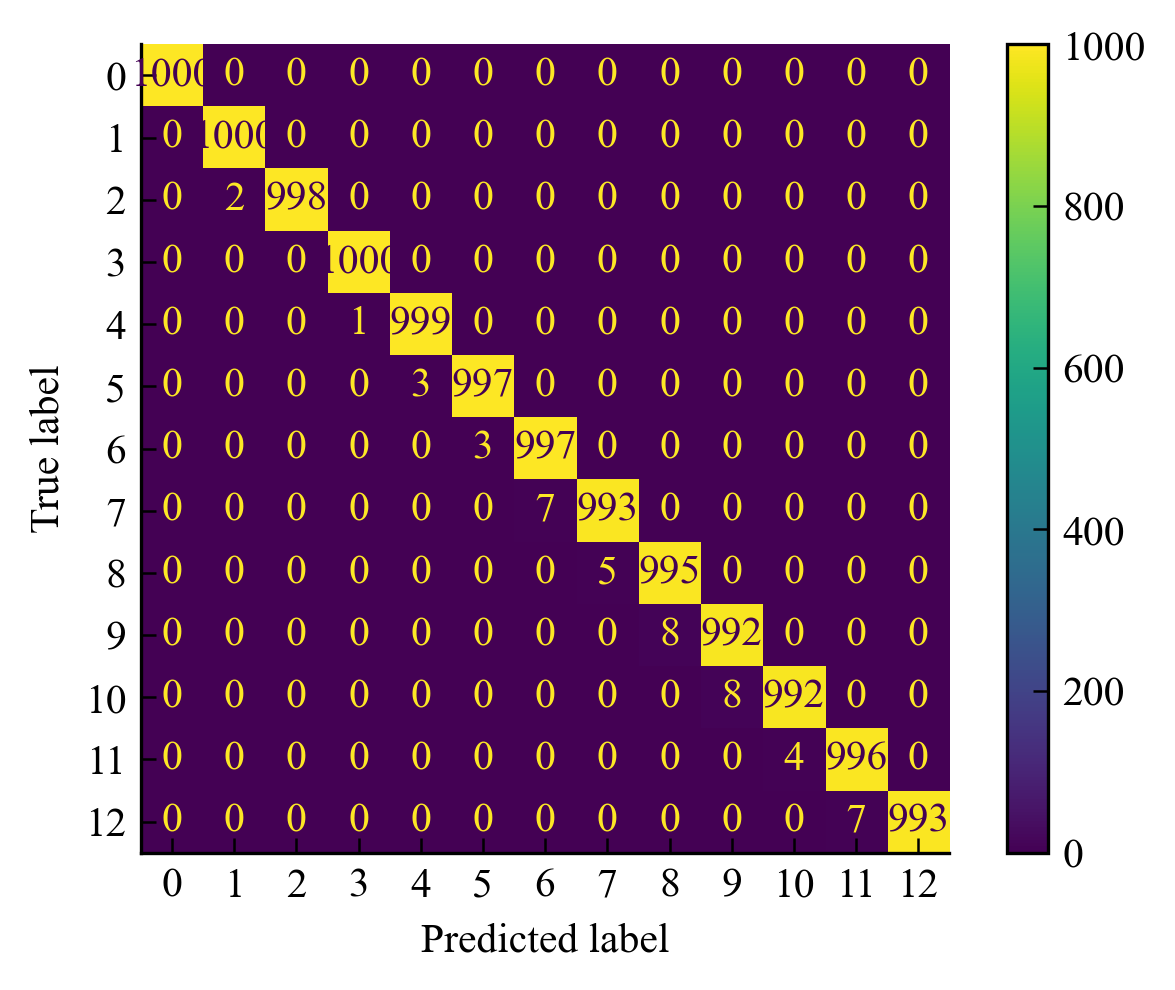

d = 15


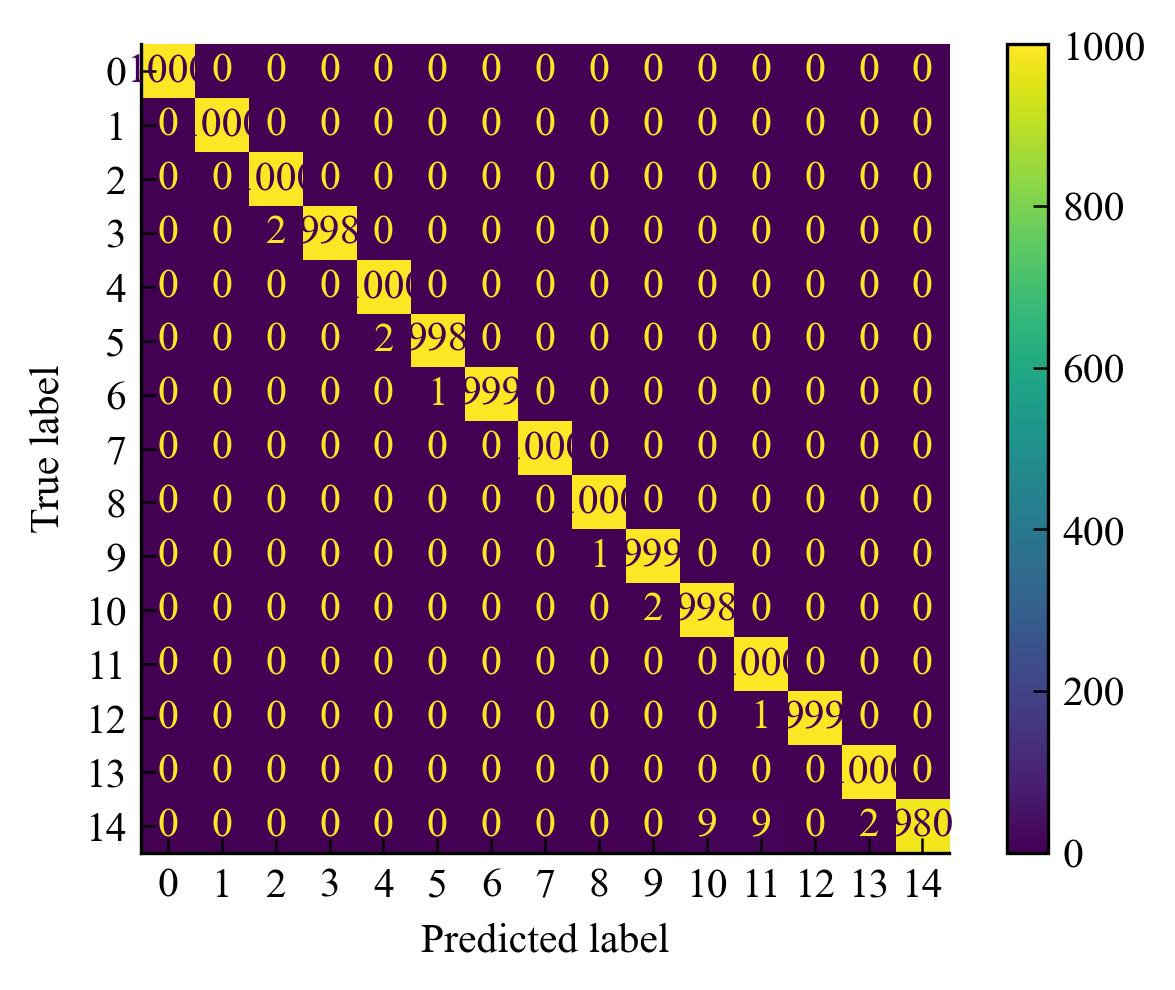

d = 19


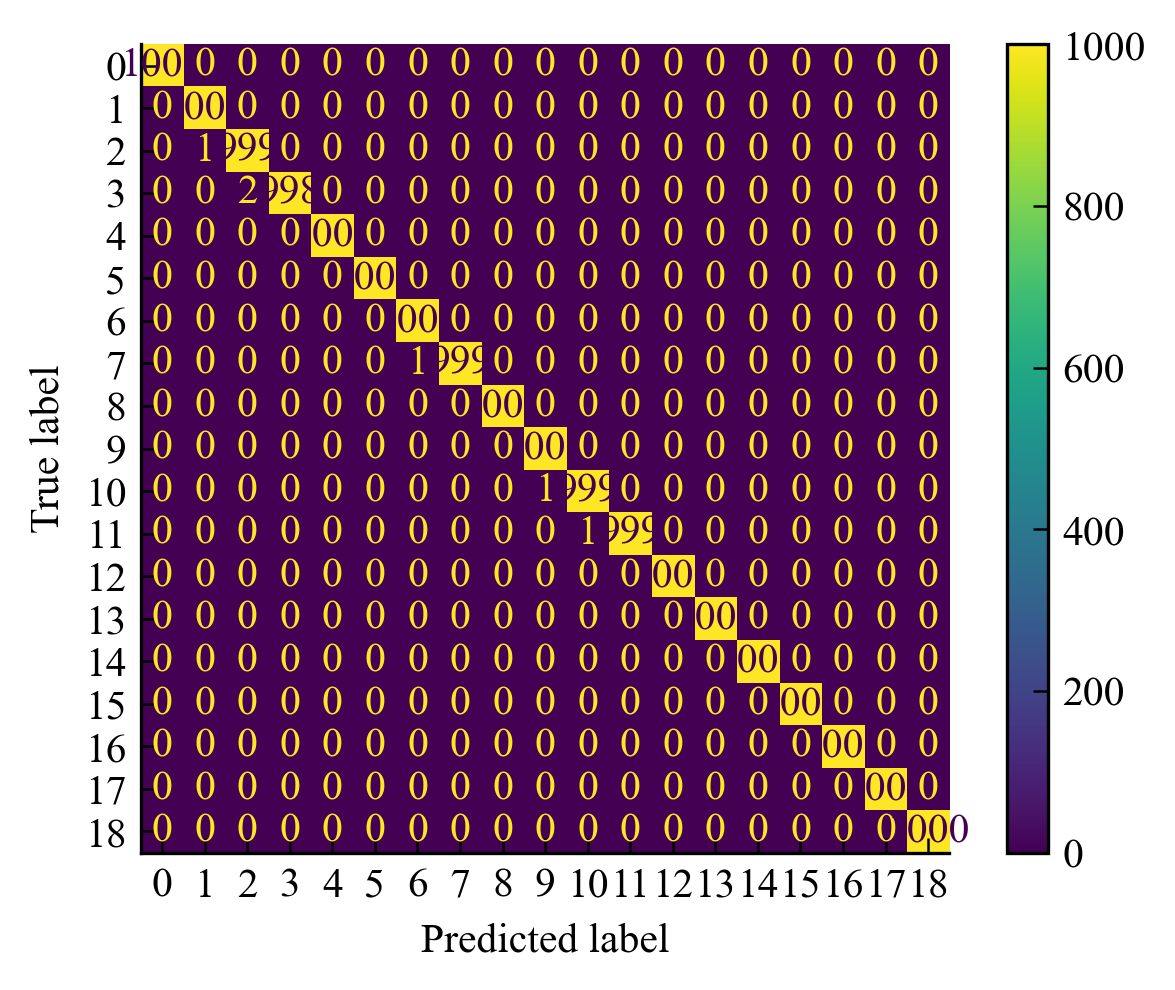

d = 23


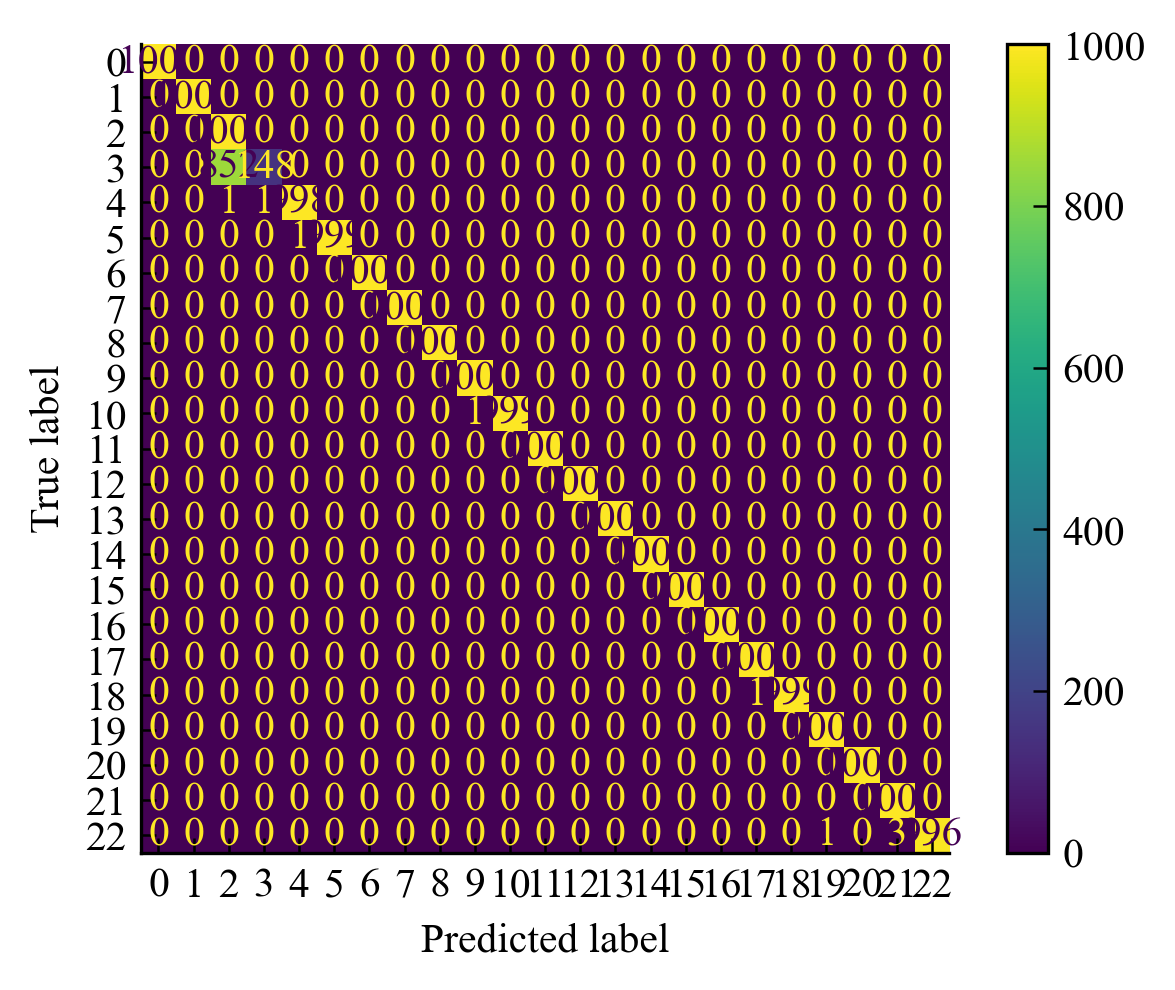

d = 25


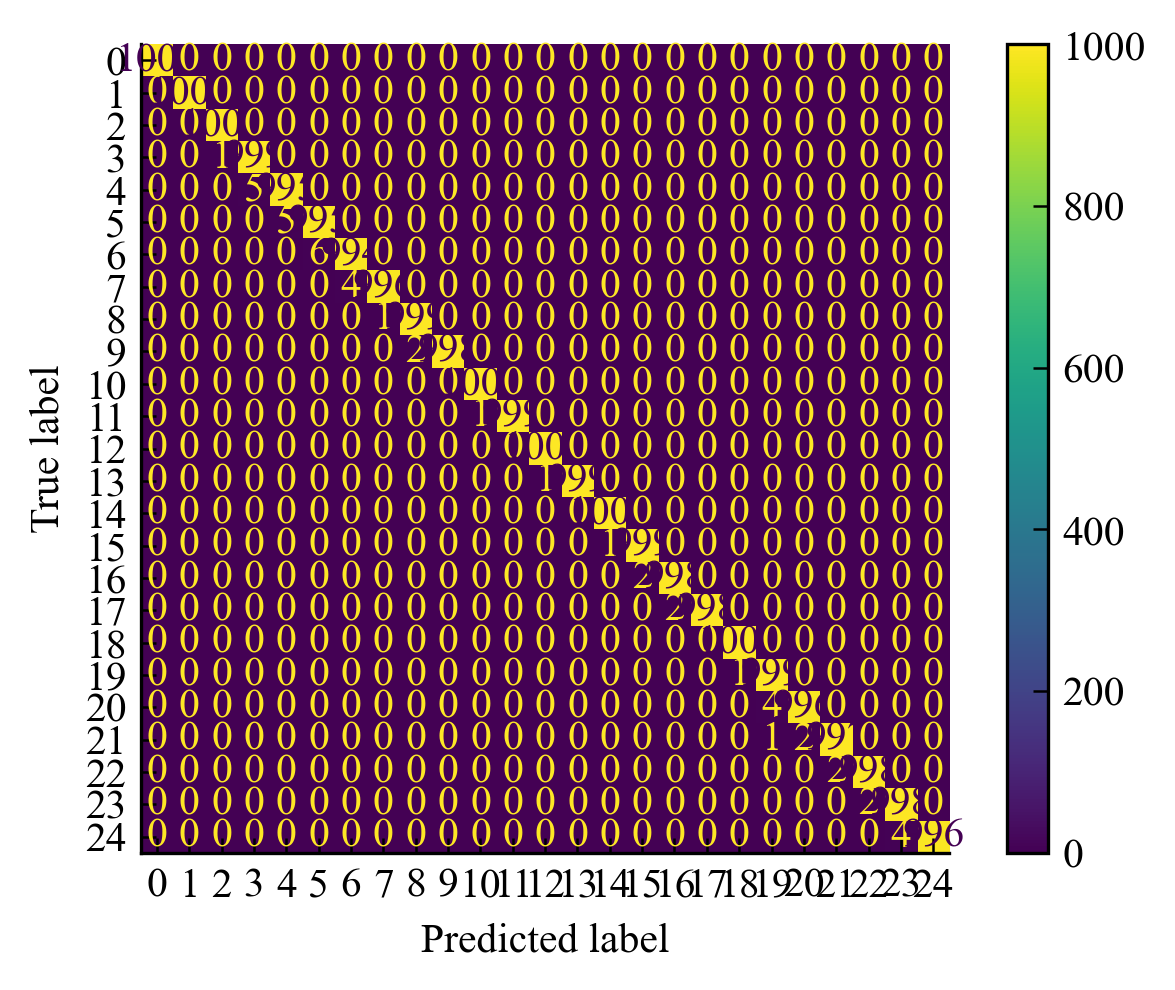

d = 28


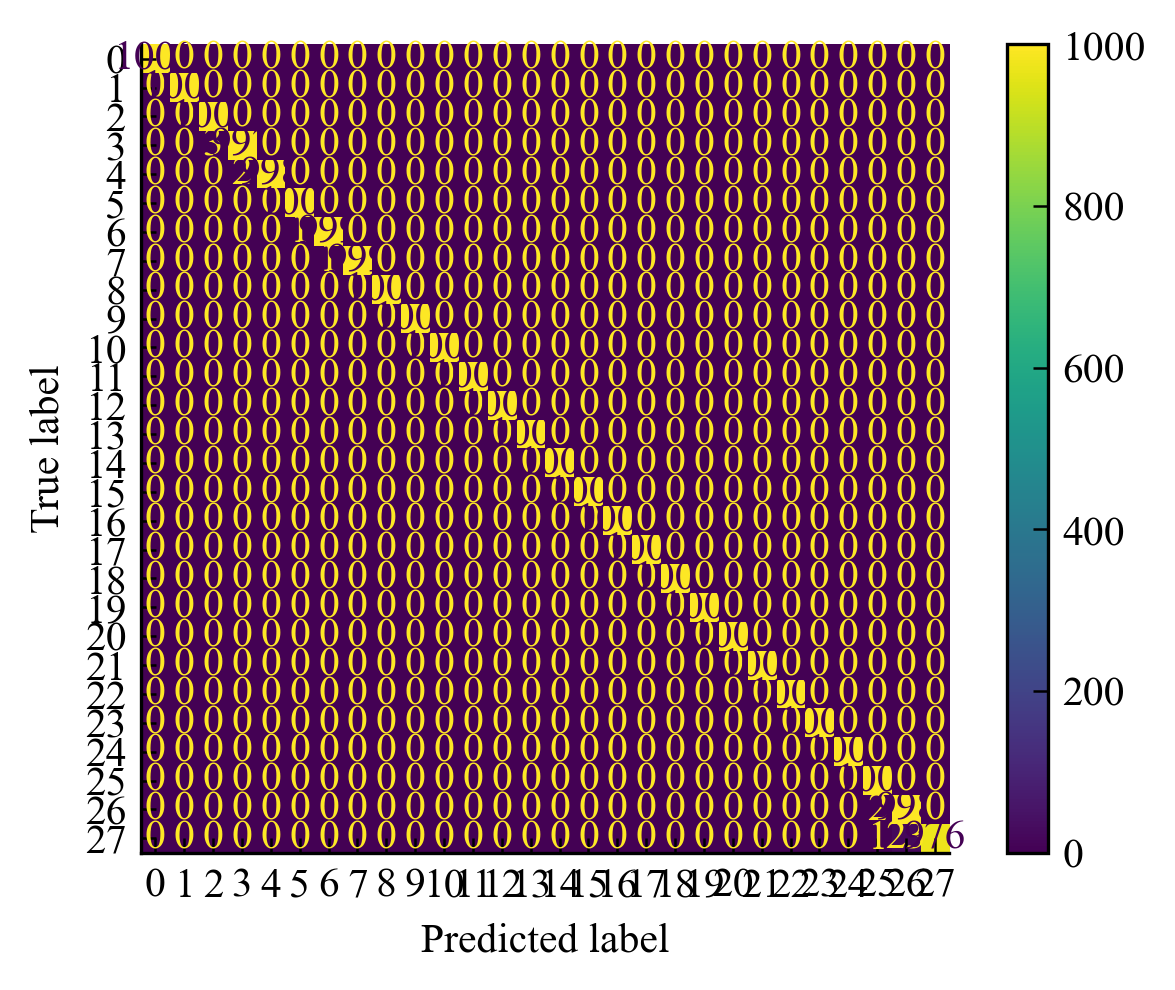

d = 33


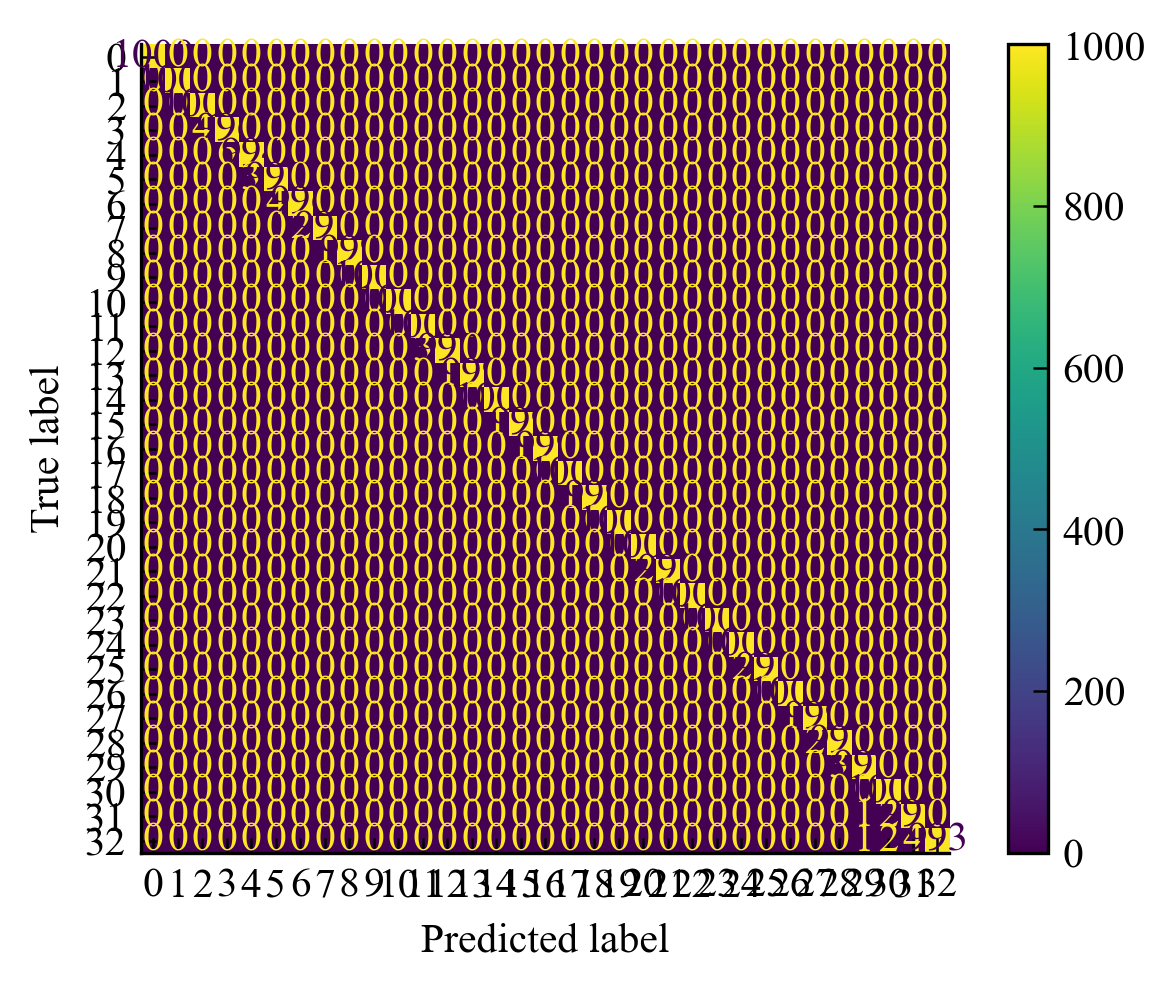

d = 35


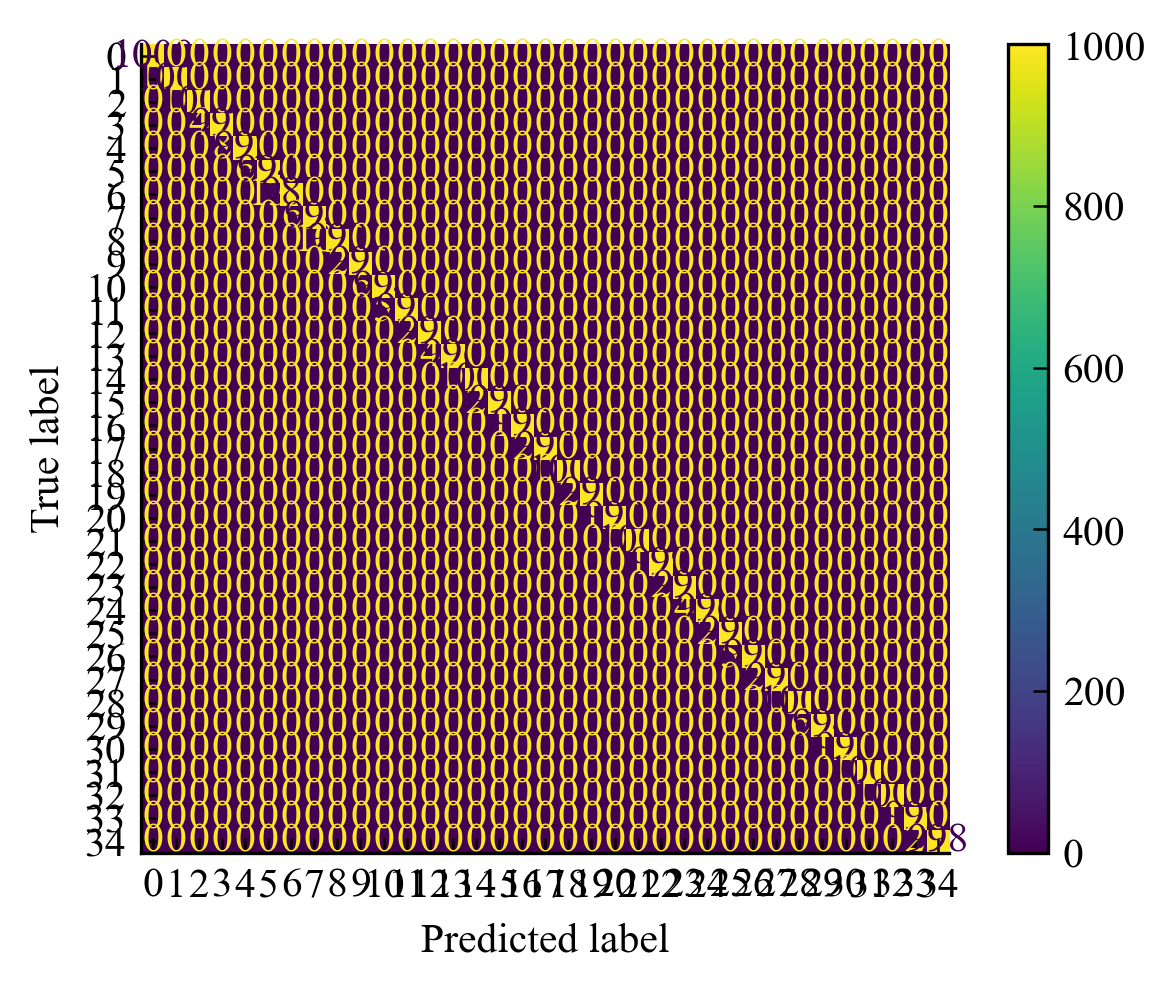

d = 4


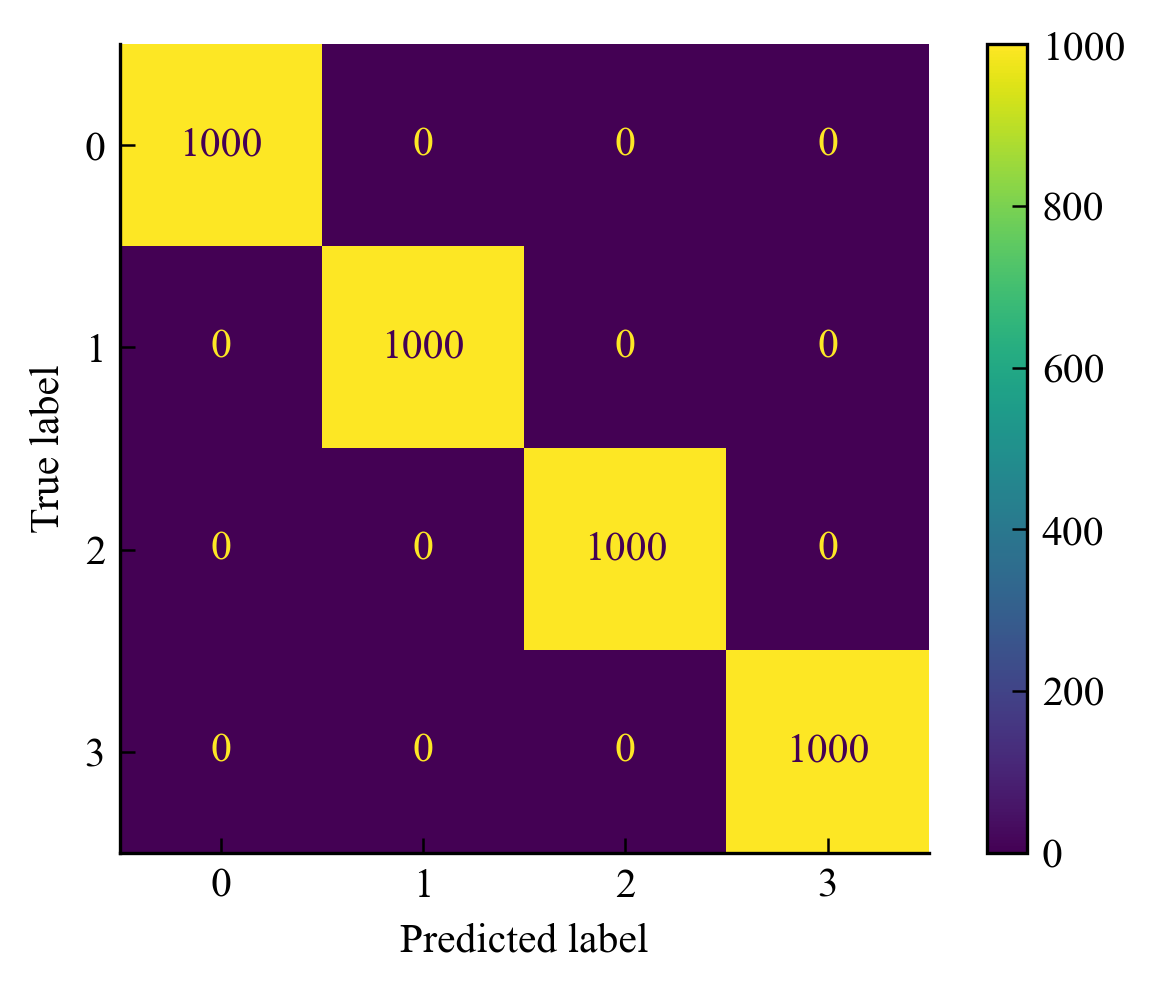

d = 6


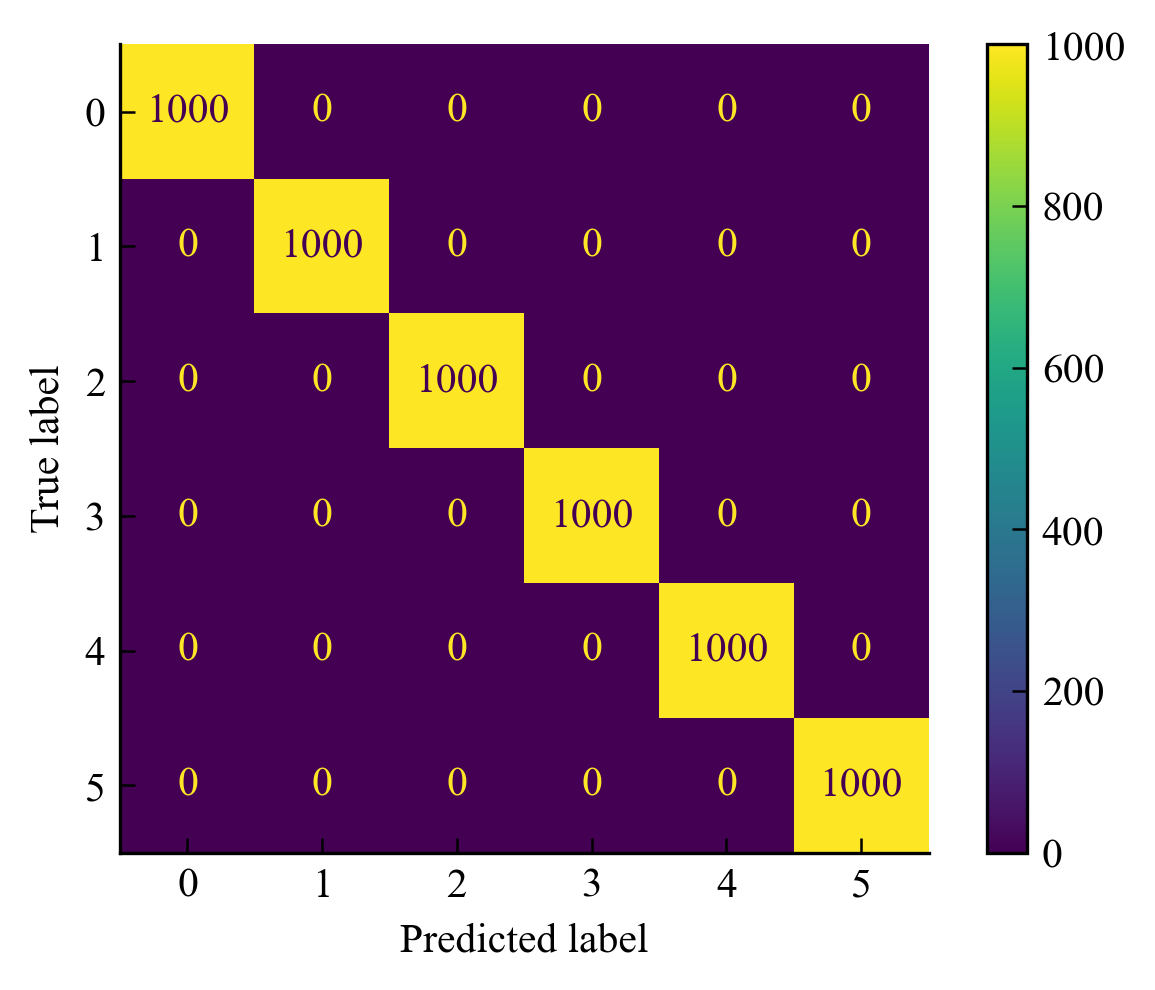

d = 7


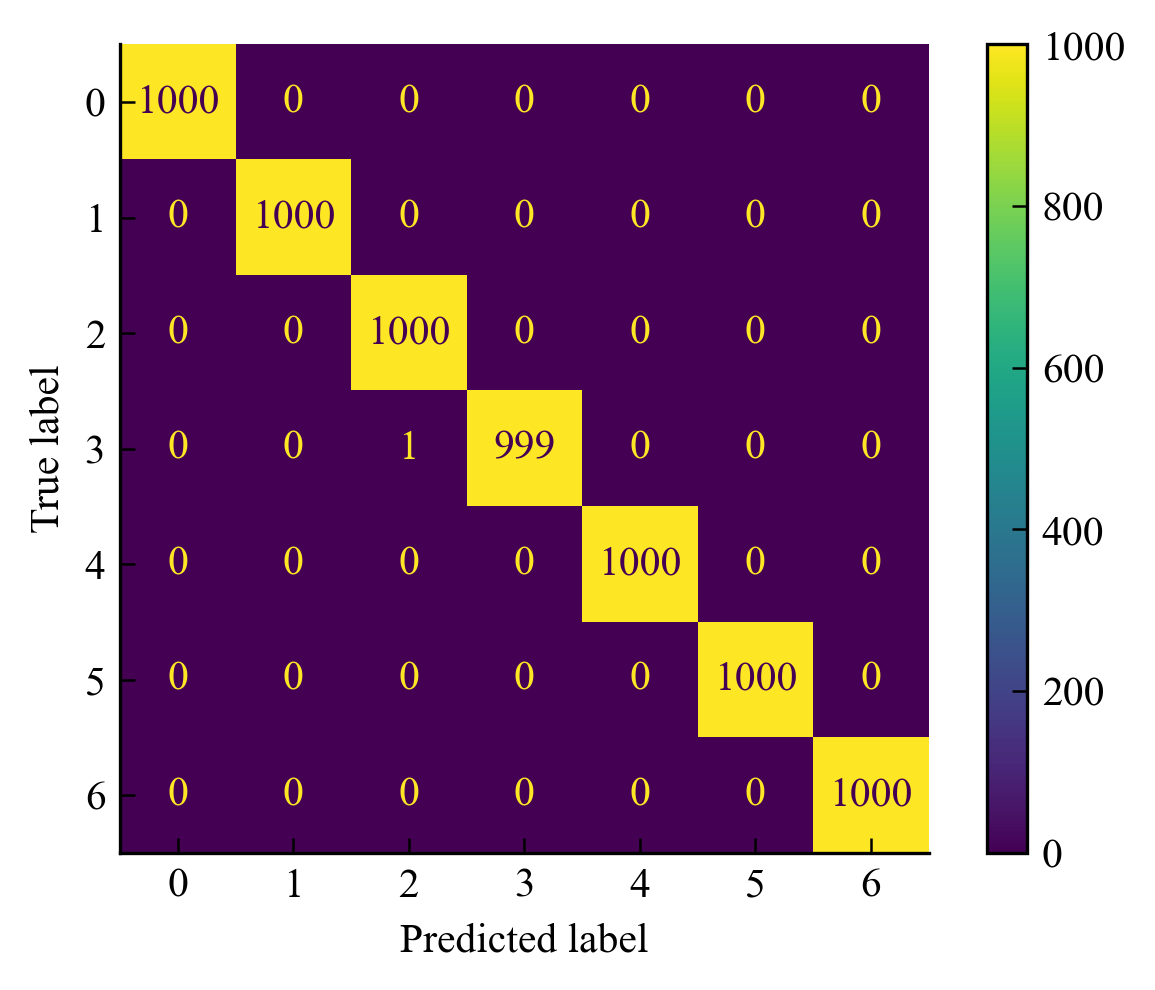

d = 9


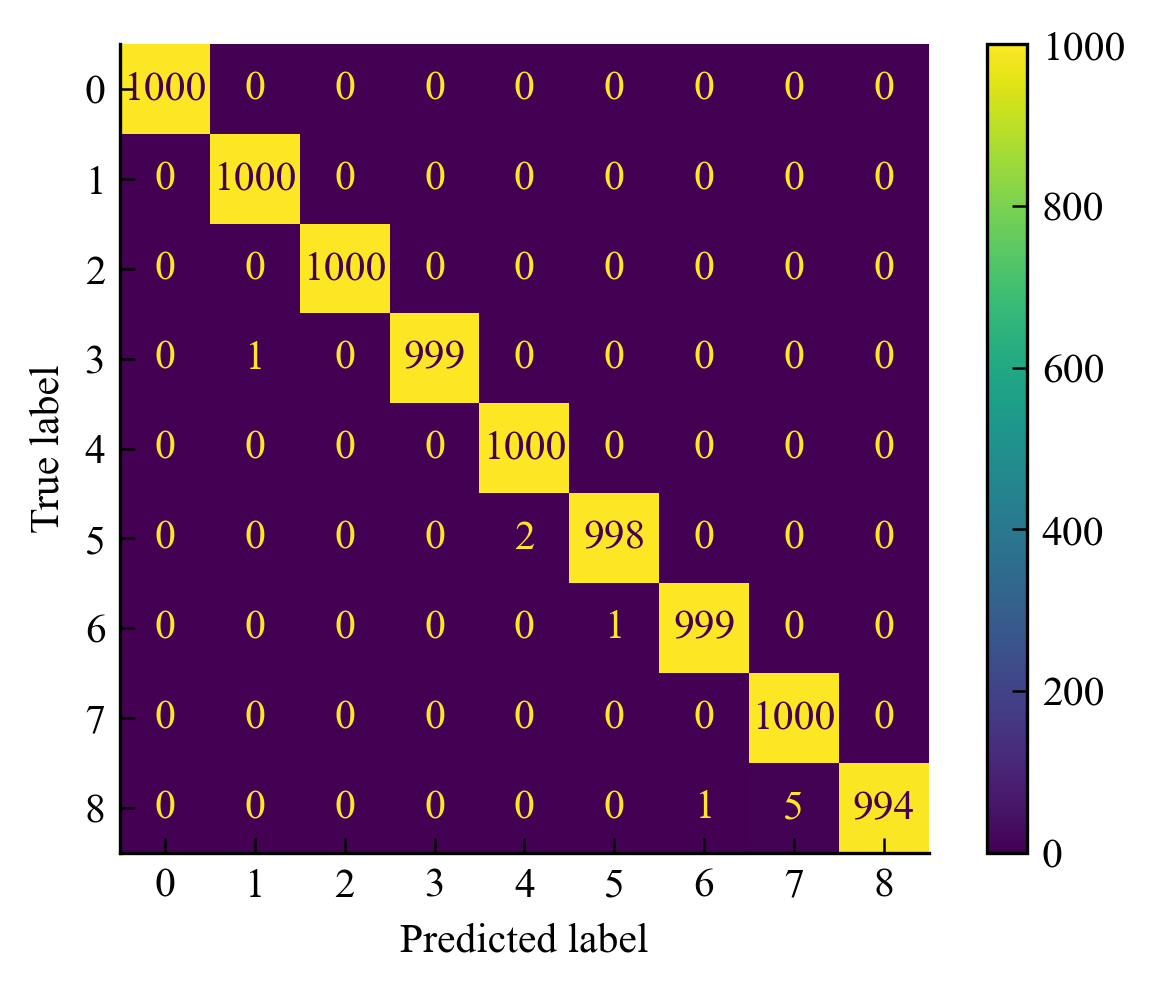

In [14]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

for filename in os.listdir('./sandbox/jordan8_results'):
    if filename.startswith("results_") and filename.endswith(".json"):
        try:
            d = int(filename.split('_')[1].split('.')[0])
        except ValueError:
            continue
            
        file_path = os.path.join('./sandbox/jordan8_results', filename)
        with open(file_path, 'r') as f:
            results = json.load(f)
        
        for entry in results:
            curr_eps = entry.get("eps")
            if curr_eps == 0:
                print("d =", d)
                preds = entry.get("predicted_classes", [])
                trues = entry.get("true_classes", [])
                cm = confusion_matrix(trues, preds)
                ConfusionMatrixDisplay(cm).plot()
                plt.show()
